In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.getcwd())

C:\Users\Ryan\Desktop\INTRO TO PYTHON


In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'B TECH GRADING SYSTEM', 'burden.csv', 'HEART FAILURE', 'heart_failure_clinical_records_dataset.csv', 'hospital_readmissions_30k.csv', 'MATPLOTLIB', 'Ryan.ipynb', 'SEABORN', 'SEMESTER_PROJECT.ipynb', 'TB_Burden_Country.csv', 'Untitled Folder', 'Untitled Folder 1', 'Untitled Folder 2', 'Untitled Folder 3', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb']


In [5]:
data = pd.read_csv("hospital_readmissions_30k.csv")
data

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,29,Male,112/80,157,31.4,No,No,4,10,Home,Yes
29996,29997,20,Other,146/83,198,30.2,No,Yes,4,1,Home,Yes
29997,29998,40,Other,131/96,275,23.3,Yes,Yes,7,2,Home,No
29998,29999,61,Other,124/75,232,34.3,No,No,5,3,Home,No


In [6]:
print(data.head())

   patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0           1   74   Other         130/72          240  31.5      Yes   
1           2   46  Female         120/92          292  36.3       No   
2           3   89   Other         135/78          153  30.3       No   
3           4   84  Female         123/80          153  31.5       No   
4           5   32   Other         135/84          205  18.4       No   

  hypertension  medication_count  length_of_stay discharge_destination  \
0           No                 5               1      Nursing_Facility   
1           No                 4               3      Nursing_Facility   
2          Yes                 1               1                  Home   
3          Yes                 3              10                  Home   
4          Yes                 6               4      Nursing_Facility   

  readmitted_30_days  
0                Yes  
1                 No  
2                 No  
3                 No  
4

In [7]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB
None


In [8]:
print(data.describe())

         patient_id           age   cholesterol           bmi  \
count  30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000     53.884233    225.260400     28.946263   
std     8660.398374     21.056485     43.585671      6.348204   
min        1.000000     18.000000    150.000000     18.000000   
25%     7500.750000     36.000000    188.000000     23.400000   
50%    15000.500000     54.000000    225.000000     28.900000   
75%    22500.250000     72.000000    263.000000     34.500000   
max    30000.000000     90.000000    300.000000     40.000000   

       medication_count  length_of_stay  
count      30000.000000    30000.000000  
mean           5.012267        5.502900  
std            3.166383        2.867298  
min            0.000000        1.000000  
25%            2.000000        3.000000  
50%            5.000000        5.000000  
75%            8.000000        8.000000  
max           10.000000       10.000000  


In [9]:
print(data.isnull().sum())

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [11]:
data[['systolic_bp', 'diastolic_bp']] = data['blood_pressure'].str.split('/', expand=True)
data['systolic_bp'] = data['systolic_bp'].astype(int)
data['diastolic_bp'] = data['diastolic_bp'].astype(int)

data.drop('blood_pressure', axis=1, inplace=True)

In [12]:
data.head()

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp
0,1,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130,72
1,2,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120,92
2,3,89,Other,153,30.3,No,Yes,1,1,Home,No,135,78
3,4,84,Female,153,31.5,No,Yes,3,10,Home,No,123,80
4,5,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135,84


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['gender', 'diabetes', 'hypertension', 
                    'discharge_destination', 'readmitted_30_days']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [14]:
data['gender'].head()

0    2
1    0
2    2
3    0
4    2
Name: gender, dtype: int64

In [15]:
data[categorical_cols].head()

,gender,diabetes,hypertension,discharge_destination,readmitted_30_days
0,2,1,0,1,1
1,0,0,0,1,0
2,2,0,1,0,0
3,0,0,1,0,0
4,2,0,1,1,0


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['age', 'cholesterol', 'bmi', 
                  'medication_count', 'length_of_stay',
                  'systolic_bp', 'diastolic_bp']

data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

In [17]:
data[numerical_cols].head()

,age,cholesterol,bmi,medication_count,length_of_stay,systolic_bp,diastolic_bp
0,0.955340,0.338181,0.402284,-0.003874,-1.570459,-0.338645,-1.459778
1,-0.374439,1.531254,1.158416,-0.319697,-0.872927,-1.020252,0.781643
2,1.667721,-1.657921,0.213251,-1.267166,-1.570459,0.002158,-0.787351
3,1.430261,-1.657921,0.402284,-0.635520,1.568436,-0.815770,-0.563209
4,-1.039328,-0.464849,-1.661326,0.311949,-0.524161,0.002158,-0.114925


In [18]:
data[numerical_cols].describe()

,age,cholesterol,bmi,medication_count,length_of_stay,systolic_bp,diastolic_bp
count,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04
mean,-5.234331e-17,-1.033840e-16,4.031146e-16,-1.203186e-16,-1.058709e-16,-3.079019e-17,-7.932025e-16
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00
min,-1.704218e+00,-1.726752e+00,-1.724337e+00,-1.582989e+00,-1.570459e+00,-1.701858e+00,-1.683920e+00
25%,-8.493598e-01,-8.548915e-01,-8.736890e-01,-9.513431e-01,-8.729269e-01,-8.839302e-01,-8.994224e-01
50%,5.498002e-03,-5.974540e-03,-7.287747e-03,-3.874095e-03,-1.753945e-01,2.158421e-03,-2.854076e-03
75%,8.603558e-01,8.658862e-01,8.748662e-01,9.435949e-01,8.709041e-01,8.882470e-01,8.937143e-01
max,1.715214e+00,1.714803e+00,1.741267e+00,1.575241e+00,1.568436e+00,1.706175e+00,1.678212e+00


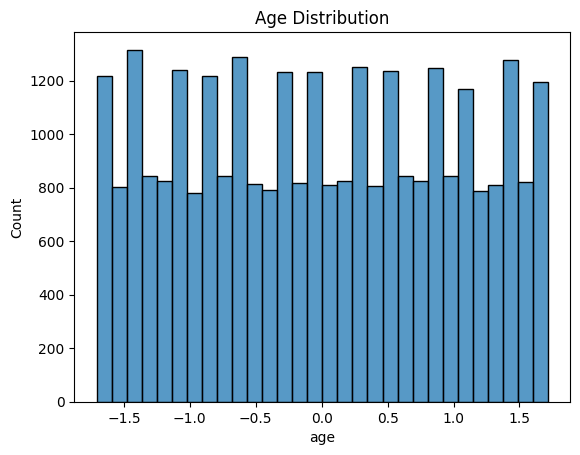

In [21]:
sns.histplot(data['age'], bins=30)
plt.title("Age Distribution")
plt.show()

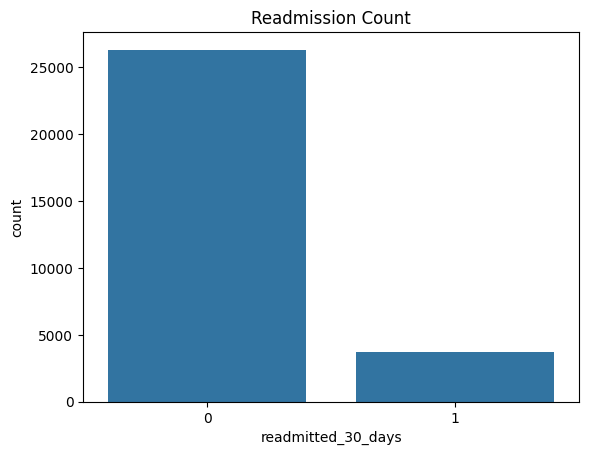

In [23]:
sns.countplot(x='readmitted_30_days', data=data)
plt.title("Readmission Count")
plt.show()

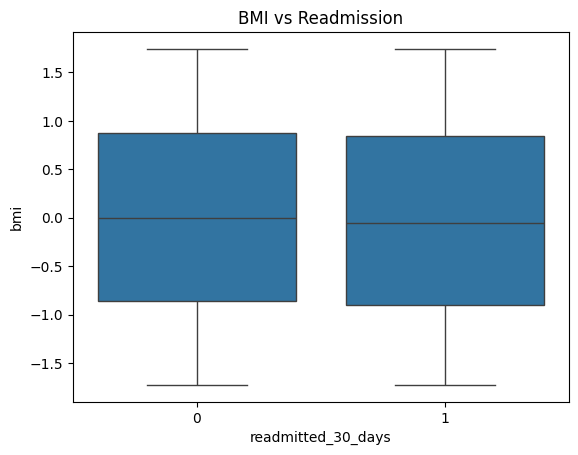

In [24]:
sns.boxplot(x='readmitted_30_days', y='bmi', data=data)
plt.title("BMI vs Readmission")
plt.show()

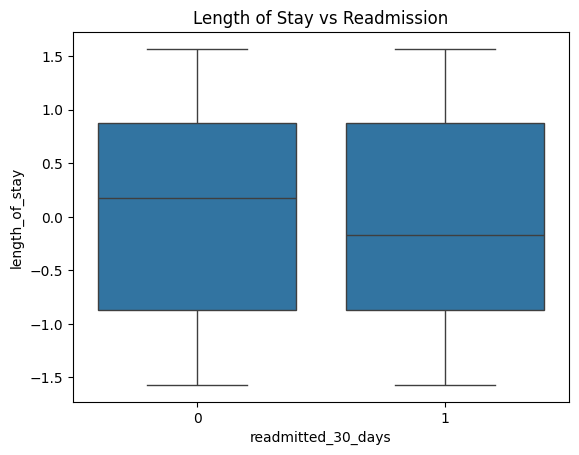

In [25]:
sns.boxplot(x='readmitted_30_days', y='length_of_stay', data=data)
plt.title("Length of Stay vs Readmission")
plt.show()

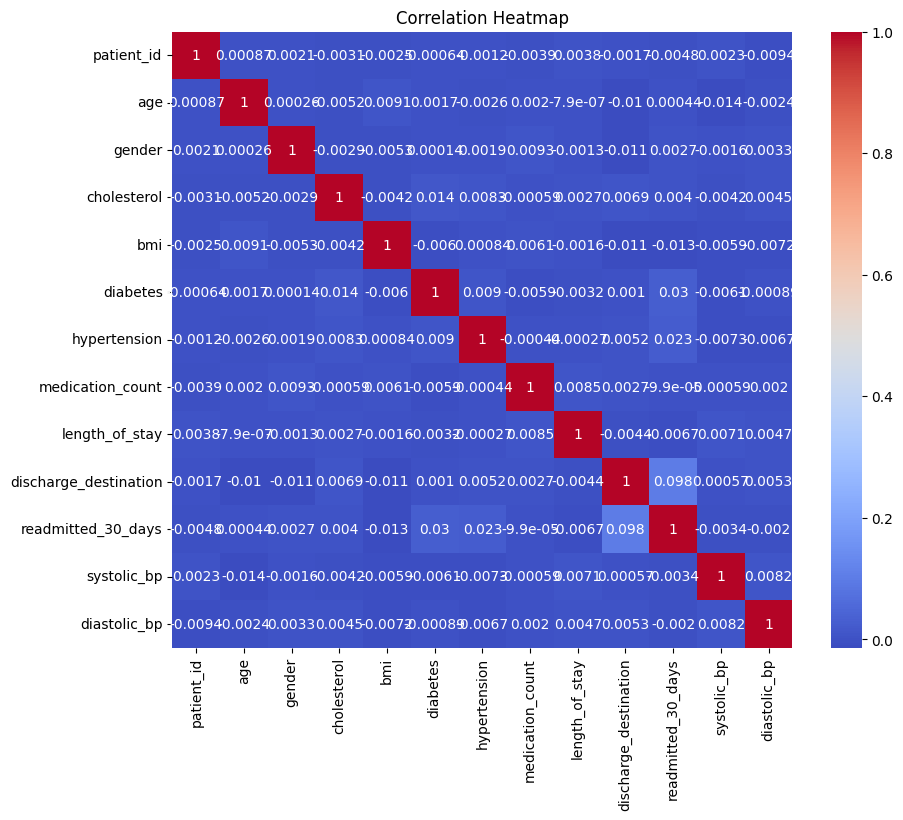

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
X = data.drop('readmitted_30_days', axis=1)
y = data['readmitted_30_days']

In [29]:
X.head()
y.head()

0    1
1    0
2    0
3    0
4    0
Name: readmitted_30_days, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000, 12)
(6000, 12)
(24000,)
(6000,)


In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\Ryan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
print(y)

0        1
1        0
2        0
3        0
4        0
        ..
29995    1
29996    1
29997    0
29998    0
29999    0
Name: readmitted_30_days, Length: 30000, dtype: int64


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [39]:
y_pred = rf.predict(X_test)

In [40]:
print(y)

0        1
1        0
2        0
3        0
4        0
        ..
29995    1
29996    1
29997    0
29998    0
29999    0
Name: readmitted_30_days, Length: 30000, dtype: int64


In [41]:
print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)

Predictions: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 1 0 0 0 0 0]


In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8716666666666667
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


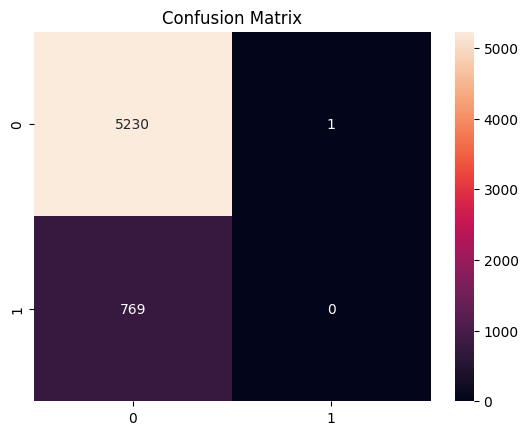

In [43]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

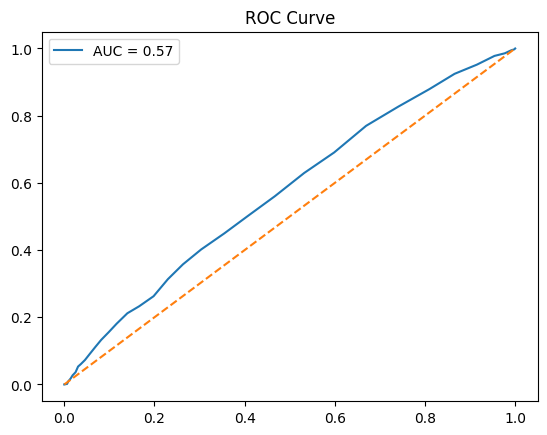

In [44]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

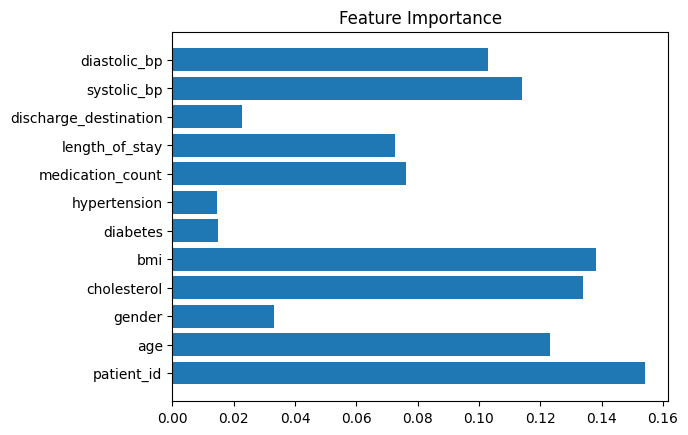

In [45]:
importance = rf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [3]:
from sklearn.ensemble import RandomForestClassifier

In [4]:
rf = RandomForestClassifier()

In [9]:
import joblib

joblib.dump(rf, "readmission_model.pkl")

print("Model saved successfully")



Model saved successfully


In [11]:
from sklearn.ensemble import RandomForestClassifier
import joblib

import os
os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/readmission_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [12]:
model = joblib.load("readmission_model.pkl")